<a href="https://colab.research.google.com/github/javigallego4/TFG/blob/main/Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import cv2
import random
import numpy as np

class HorizontalFlip(object):
  '''
  Horizontal flipping to the image and the corresponding mask.
  '''

  def __call__(self, img, mask):
    return(cv2.flip(img, 0), cv2.flip(mask, 0)) 
    
class VerticalFlip(object):
  '''
  Vertical flipping to the image and the corresponding mask.
  '''

  def __call__(self, img, mask):
    return(cv2.flip(img, 2), cv2.flip(mask, 2))
    
class SimultaneousFlipping(object):
  '''
  Both horizontal and vertical flipping to the image and corresponding mask.
  '''

  def __call__(self, img, mask):
    return(cv2.flip(img, -2), cv2.flip(img, -2))

class Augment(object):
  '''
  Composes all the transforms together.

  Parameters: 
    augs -- list of all augmentations to make
  '''

  def __init__(self, augs):
    self.augs = augs

  def __call__(self, img, mask):
    for augmentation in augs: 
      img, mask = augmentation(img, mask)

  

[Explicación Pansharpening](http://www.gisandbeers.com/pansharpening-mejorando-la-resolucion-de-imagenes-satelite/)

[Gdal_pansharpening (Stack Overflow)](https://gis.stackexchange.com/questions/353605/calling-gdal-pansharpen-py-from-another-python-script)

[GDAL Doc](https://gdal.org/programs/gdal_pansharpen.html)

[OpenCV - Super resolution](https://towardsdatascience.com/deep-learning-based-super-resolution-with-opencv-4fd736678066)

[OpenCV - Super-Resolution](https://pyimagesearch.com/2020/11/09/opencv-super-resolution-with-deep-learning/)

[Tensorflow - Super Resolution](https://www.tensorflow.org/lite/examples/super_resolution/overview)

In [21]:
from google.colab import drive
drive.mount('/content/gdrive')

from IPython.display import clear_output, display_html
import gc; gc.enable()
import warnings
import os
from pathlib import Path
from tqdm import tqdm

# Basic libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sc
from scipy import stats

# Preprocessing libraries
from sklearn.preprocessing import *
import cv2
import albumentations as A

# Library for .tiff files
!pip install tifffile
import tifffile as tiff

# PyTorch 
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau 
from PIL import Image

clear_output()
print('Number of CPUs: ', os.cpu_count())

DEBUG = False

Number of CPUs:  2


In [2]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

# Obtenemos todos los nºs de polígonos que nos dan en la siguiente ruta. 

BASE_PATH = "/content/gdrive/MyDrive/juniper/WV3/"
polygon_numbers = os.listdir(BASE_PATH)
polygon_numbers = pd.Series(polygon_numbers).str.split('_', n = 2, expand = True)[1]
polygon_numbers = list(polygon_numbers)
polygon_numbers = sorted(polygon_numbers)

# Guardamos en arrays cada una de las imágenes y máscaras.

p_images, m_images, p_masks, m_masks = [], [], [], []
def load_images(polygon_number):
  # Panchromatic Images
  p_images.append(tiff.imread(BASE_PATH + "polygon_{}/panchromatic.tif".format(polygon_number)))
  p_masks.append(tiff.imread(BASE_PATH + "polygon_{}/mask_panchromatic.tif".format(polygon_number)))
  
  # Multispectral Images
  # Hacemos un permute para poner las imágenes en el formato PyTorch
  m_images.append(tiff.imread(BASE_PATH + "polygon_{}/multispectral.tif".format(polygon_number)))
  m_masks.append(tiff.imread(BASE_PATH + "polygon_{}/mask_multispectral.tif".format(polygon_number)))

def fit_all_images(polygon_numbers):
  with ThreadPoolExecutor(2) as p:
      for i in tqdm(p.map(load_images, polygon_numbers), total=len(polygon_numbers)):
          pass

fit_all_images(polygon_numbers)

if DEBUG: 
  print('\nType: ', type(m_images[0]))
  print('Image Shape', m_images[0].shape)
  print('Mask Shape', m_masks[0].shape)

  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
  axes[0].imshow(m_images[1][:,:,:3])
  axes[1].imshow(m_masks[1])

  resized_image = cv2.resize(m_images[1], (215, 256), interpolation = cv2.INTER_NEAREST)
  resized_mask = cv2.resize(m_masks[1], (215, 256), interpolation = cv2.INTER_NEAREST)

  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
  axes[0].imshow(resized_image[:,:,:3])
  axes[1].imshow(resized_mask)

  resized_image = cv2.resize(resized_image, (21, 25), interpolation = cv2.INTER_NEAREST)
  resized_mask = cv2.resize(resized_mask, (21, 25), interpolation = cv2.INTER_NEAREST)

  fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
  axes[0].imshow(resized_image[:,:,:3])
  axes[1].imshow(resized_mask)

  # Transpose the image and mask
  image = m_images[1].transpose(1,0,2)
  mask = m_masks[1].transpose(1,0)

  # Flip the image and mask vertically
  image = cv2.flip(image, 1)
  mask = cv2.flip(mask, 1)

100%|██████████| 261/261 [03:22<00:00,  1.29it/s]


# Pansharpening

In [22]:
def inverse_pca_image(sharpened_img, pca):
  """
    Performs inverse PCA transformation to the given image.

    Parameters:
    - sharpened_img: image to be transformed
    - pca: PCA object with loadings from previous fit_transform()
  """

  X = sharpened_img.permute(1,2,0).numpy()

  b0 = X[:,:,0]
  b1 = X[:,:,1]
  b2 = X[:,:,2]
  b3 = X[:,:,3]
  b4 = X[:,:,4]
  b5 = X[:,:,5]
  b6 = X[:,:,6]
  b7 = X[:,:,7]

  pca_df = pd.DataFrame({'B0': b0.flatten(), 'B1': b1.flatten(), 'B2': b2.flatten(), 'B3':b3.flatten(), 
              'B4': b4.flatten(), 'B5': b5.flatten(), 'B6': b6.flatten(), 'B7':b7.flatten()})

  img = pca.inverse_transform(pca_df)

  for i in range(8): 
    sharpened_img[i, :, :] = torch.from_numpy(img[:,i].reshape((sharpened_img.shape[1], sharpened_img.shape[2])))

  return sharpened_img

def histogram_match(pan, band):
    """
    Performs histogram matching between the panchromatic image and the multispectral band given.

    Parameters:
    - pan: torch tensor of shape (height, width)
    - band: torch tensor of shape (height, width)

    Returns:
    - matched_panchromatic: histogram matched PAN imagery
    """

    # Fórmula UGR: https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=&cad=rja&uact=8&ved=2ahUKEwicxYCXrYv9AhXRhqQKHYoUDFQQFnoECAkQAQ&url=https%3A%2F%2Fccia.ugr.es%2Fvip%2Ffiles%2Fbooks%2Fpaper_amro_mateos.pdf&usg=AOvVaw3wn01QiErGCJLtNZUg-oKe
    matched_panchromatic = (pan - pan.mean()) * (band.std() / pan.std()) + band.mean()

    return matched_panchromatic

def pansharpen_image(multispectral_image, panchromatic_image, method):
    """
    Pansharpens the given MS image based on different techniques.

    Parameters:
    - multispectral_image: torch tensor of shape (channels, height, width)
    - panchromatic_image: torch tensor of shape (height, width)
    - method: type of pansharpening technique

    Returns:
    - sharpened_img: torch tensor with same shape as input multispectral image
    """
    
    if method == 'PCA': 
      # Forward Transform: perform PCA and replace 1st component with panchromatic band
      sharpened_img, pca = pca_image(multispectral_image, 8, True)
      sharpened_img = torchvision.transforms.Resize((panchromatic_image.shape[0], panchromatic_image.shape[1]))(sharpened_img)

      # Histogram Matching: the PAN Imagery is matched with the PC1 band
      matched_panchromatic = histogram_match(panchromatic_image, sharpened_img[0, :, :])

      # Component Substitution
      sharpened_img[0, :, :] = matched_panchromatic

      # Reverse Transform: undo PCA
      sharpened_img = inverse_pca_image(sharpened_img, pca)
      
    if method == 'Simple Mean':
      multispectral_image = torchvision.transforms.Resize((panchromatic_image.shape[0], panchromatic_image.shape[1]))(multispectral_image)
      sharpened_img = torch.randn(multispectral_image.shape[0], multispectral_image.shape[1], multispectral_image.shape[2])
      for i in range(multispectral_image.shape[0]):
        # Histogram Matching for each band
        matched_panchromatic = histogram_match(panchromatic_image, multispectral_image[i, :, :])        
        sharpened_img[i, :, :] = 0.5 * (multispectral_image[i, :, :] + matched_panchromatic)

    if method == 'Brovey': 
        multispectral_image = torchvision.transforms.Resize((panchromatic_image.shape[0], panchromatic_image.shape[1]))(multispectral_image)
        sharpened_img = torch.randn(multispectral_image.shape[0], multispectral_image.shape[1], multispectral_image.shape[2])

        M = 0
        for i in range(multispectral_image.shape[0]):
          M += multispectral_image[i, :, :]
        M /= multispectral_image.shape[0]

        for i in range(multispectral_image.shape[0]):
          # Histogram Matching for each band
          matched_panchromatic = histogram_match(panchromatic_image, multispectral_image[i, :, :])
          sharpened_img[i, :, :] = (matched_panchromatic / M) * multispectral_image[i, :, :]

    if method == 'HSV': 
      multispectral_image = torchvision.transforms.Resize((panchromatic_image.shape[0], panchromatic_image.shape[1]))(multispectral_image)
      # Forward Transform
      red = multispectral_image[4, :, :]
      green = multispectral_image[2, :, :]
      blue = multispectral_image[1, :, :]

      I = 0.577 * (red+green+blue)
      v1 = -0.408 * (red+green) + 0.816 * blue
      v2 = -0.707 * (red+green) + 1.703 * blue

      H = torch.atan(v2/v1)
      S = torch.sqrt(torch.pow(v1,2) + torch.pow(v2,2))

      # Histogram Matching
      matched_panchromatic = histogram_match(panchromatic_image, I)

      # Reverse Transformation
      new_red = 0.577 * matched_panchromatic - 0.408 * v1 - 0.707 * v2
      new_green = 0.577 * matched_panchromatic - 0.408 * v1 - 0.816 * v2
      new_blue = 0.577 * matched_panchromatic - 0.816 * v1

      sharpened_img = multispectral_image
      sharpened_img[4, :, :] = new_red
      sharpened_img[2, :, :] = new_green
      sharpened_img[1, :, :] = new_blue

    if method == 'IHS1':
      multispectral_image = torchvision.transforms.Resize((panchromatic_image.shape[0], panchromatic_image.shape[1]))(multispectral_image)
      # Forward Transform
      red = multispectral_image[4, :, :]
      green = multispectral_image[2, :, :]
      blue = multispectral_image[1, :, :]

      I = 1/np.sqrt(3) * (red+green+blue)
      v1 = -1/np.sqrt(6) * (red+green) + 2/np.sqrt(6) * blue
      v2 = 1/np.sqrt(2) * (-red+green)

      H = torch.atan(v2/v1)
      S = torch.sqrt(torch.pow(v1,2) + torch.pow(v2,2))

      # Histogram Matching
      matched_panchromatic = histogram_match(panchromatic_image, I)

      # Reverse Transformation
      v1 = S * torch.cos(H)
      v2 = S * torch.sin(H)

      new_red = 1/np.sqrt(3) * matched_panchromatic -1/np.sqrt(6) * v1 - 1/np.sqrt(2) * v2
      new_green = 1/np.sqrt(3) * matched_panchromatic -1/np.sqrt(6) * v1 + 1/np.sqrt(2) * v2
      new_blue = 1/np.sqrt(3) * matched_panchromatic + 2/np.sqrt(6) * v1

      sharpened_img = multispectral_image
      sharpened_img[4, :, :] = new_red
      sharpened_img[2, :, :] = new_green
      sharpened_img[1, :, :] = new_blue

    if method == 'IHS2':
      multispectral_image = torchvision.transforms.Resize((panchromatic_image.shape[0], panchromatic_image.shape[1]))(multispectral_image)
      # Forward Transform
      red = multispectral_image[4, :, :]
      green = multispectral_image[2, :, :]
      blue = multispectral_image[1, :, :]

      I = 1/3 * (red+green+blue)
      v1 = -1/np.sqrt(6) * (red+green) + 2/np.sqrt(6) * blue
      v2 = 1/np.sqrt(6) * red - 2 /np.sqrt(6) * green

      H = torch.atan(v2/v1)
      S = torch.sqrt(torch.pow(v1,2) + torch.pow(v2,2))

      # Histogram Matching
      matched_panchromatic = histogram_match(panchromatic_image, I)

      # Reverse Transformation
      v1 = S * torch.cos(2*np.pi*H)
      v2 = S * torch.sin(2*np.pi*H)

      new_red = 1 * matched_panchromatic -0.204124 * v1 - 0.612372 * v2
      new_green = 1 * matched_panchromatic -0.204124 * v1 + 0.612372 * v2
      new_blue = 1 * matched_panchromatic + 0.408248 * v1

      sharpened_img = multispectral_image
      sharpened_img[4, :, :] = new_red
      sharpened_img[2, :, :] = new_green
      sharpened_img[1, :, :] = new_blue

    if method == 'IHS3':
      multispectral_image = torchvision.transforms.Resize((panchromatic_image.shape[0], panchromatic_image.shape[1]))(multispectral_image)
      # Forward Transform
      red = multispectral_image[4, :, :]
      green = multispectral_image[2, :, :]
      blue = multispectral_image[1, :, :]

      I = 1/3 * (red+green+blue)
      v1 = -1/np.sqrt(6) * (red+green) + 2/np.sqrt(6) * blue
      v2 = 1/np.sqrt(6) * red - 1/np.sqrt(6) * green

      H = torch.atan(v2/v1)
      S = torch.sqrt(torch.pow(v1,2) + torch.pow(v2,2))

      # Histogram Matching
      matched_panchromatic = histogram_match(panchromatic_image, I)

      # Reverse Transformation
      new_red = 1 * matched_panchromatic -1/np.sqrt(6) * v1 +3/np.sqrt(6) * v2
      new_green = 1 * matched_panchromatic -1/np.sqrt(6) * v1 -3/np.sqrt(6) * v2
      new_blue = 1 * matched_panchromatic + 2/np.sqrt(6) * v1

      sharpened_img = multispectral_image
      sharpened_img[4, :, :] = new_red
      sharpened_img[2, :, :] = new_green
      sharpened_img[1, :, :] = new_blue

    #if method == 'Wavelet': 

    #if method == ''

    return sharpened_img

def pansharpening(method):
  """
  Performs pansharpening to every image in the dataset.
  """

  for i in range(len(p_images)):
    img = pansharpen_image(torch.from_numpy(m_images[i]).permute(2,0,1), torch.from_numpy(p_images[i]), method)
    m_images[i] = img.permute(1,2,0).numpy()

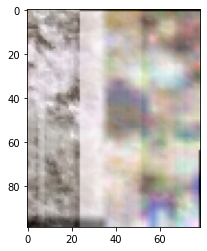

TypeError: ignored

In [23]:
if DEBUG: 
  #scaling()
  for i in range(5):

    # Vemos como sería la imagen multispectral con la resolucion de la pancromática.
    multispectral_image = torchvision.transforms.Resize((p_images[i].shape[0], p_images[i].shape[1]))(torch.from_numpy(m_images[i]).permute(2,0,1))
    plt.imshow(multispectral_image[:3, :, :].permute(1,2,0))
    plt.show()

    # Aplicamos el pansharpening para observar el cambio.
    img = pansharpening(torch.from_numpy(m_images[i]).permute(2,0,1), torch.from_numpy(p_images[i]), 'IHS3')
    fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 8))

    axes[0,0].imshow(img[:3, :, :].permute(1,2,0))
    axes[0,1].imshow(img[:3, :, :].permute(1,2,0))
    axes[0,1].imshow(p_masks[i], alpha = .5)

    axes[1,0].imshow(p_images[i], cmap = 'gray')
    axes[1,1].imshow(p_images[i])
    axes[1,1].imshow(p_masks[i], alpha = .5)
    plt.show()

# Scaling

In [ ]:
def scale_panchromatic_image(image, transformer = MinMaxScaler()):
  '''Returns input panchromatic image with its values being scaled to the [0,1] interval. '''

  img = transformer.fit_transform(image, )
  return img

def scale_multispectral_image(image, transformer = MinMaxScaler()):
  '''Returns input multispectral image with its values being scaled to the [0,1] interval. '''

  b0 = image[:,:,0]
  b1 = image[:,:,1]
  b2 = image[:,:,2]
  b3 = image[:,:,3]
  b4 = image[:,:,4]
  b5 = image[:,:,5]
  b6 = image[:,:,6]
  b7 = image[:,:,7]

  # As before, we perform some scaling first
  sc = transformer
  b0 = sc.fit_transform(b0)
  b1 = sc.fit_transform(b1)
  b2 = sc.fit_transform(b2)
  b3 = sc.fit_transform(b3)
  b4 = sc.fit_transform(b4)
  b5 = sc.fit_transform(b5)
  b6 = sc.fit_transform(b6)
  b7 = sc.fit_transform(b7)

  img = np.dstack([b0, b1, b2, b3, b4, b5, b6, b7])
  return img

def scaling():
  '''Pipeline function for value scaling. '''

  for i in range(len(p_images)):
    p_images[i] = scale_panchromatic_image(p_images[i])
    m_images[i] = scale_multispectral_image(m_images[i])

# Data Augmentation

In [24]:
def HorizontalFlip():
  '''Performs horizontal flipping. '''

  for i in range(len(polygon_numbers)):
    m_images.append(cv2.flip(m_images[i], 1))
    p_masks.append(cv2.flip(p_masks[i], 1))

def VerticalFlip():
  '''Performs vertical flipping. '''

  for i in range(len(polygon_numbers)):
    m_images.append(cv2.flip(m_images[i], 0))
    p_masks.append(cv2.flip(p_masks[i], 0))

def VHFlip(): 
  '''Performs both horizontal and vertical flipping. '''

  for i in range(len(polygon_numbers)):
    m_images.append(cv2.flip(m_images[i], -1))
    p_masks.append(cv2.flip(p_masks[i], -1))

def Rotation90():
  '''Performs a 90 degrees rotation on the images'''

  for i in range(len(polygon_numbers)):

    # Transpose the image
    image = image.transpose(1,0,2)
    # Flip the image vertically
    image = cv2.flip(image, 1)
    m_images.append(cv2.flip(m_images[i], -1))
    p_masks.append(cv2.flip(p_masks[i], -1))
  
# source: https://www.kaggle.com/safavieh/image-augmentation-using-skimage
import random
import pylab as pl 

def randRange(a, b):
    '''
    a utility function to generate random float values in desired range
    '''
    return pl.rand() * (b - a) + a

def randomCrop(im, msk):
    '''
    croping the image in the center from a random margin from the borders
    '''
    margin = 1/5
    start = [int(randRange(0, im.shape[0] * margin)),
             int(randRange(0, im.shape[1] * margin))]
    end = [int(randRange(im.shape[0] * (1-margin), im.shape[0])), 
           int(randRange(im.shape[1] * (1-margin), im.shape[1]))]
    cropped_image = (im[start[0]:end[0], start[1]:end[1]])
    cropped_mask = (msk[start[0]:end[0], start[1]:end[1]])
    return cropped_image, cropped_mask

def Cropping():
  ''' Applying 10 random croppings to all the images.'''
  
  for i in range(len(polygon_numbers)):
    for j in range(10):
      img, mask = randomCrop(m_images[i], p_masks[i])
      m_images.append(img)
      p_masks.append(mask)

def GaussianBlur():
  '''Applies gaussian blur to the images.'''

  for i in range(len(polygon_numbers)):
    m_images.append(A.GaussianBlur(p=1.0)(image=m_images[i])['image'])
    p_masks.append(p_masks[i])

def data_augmentation():
  '''Performs data augmentation over images and masks. '''

  HorizontalFlip()
  VerticalFlip()
  VHFlip()
  Cropping()
  #GaussianBlur()

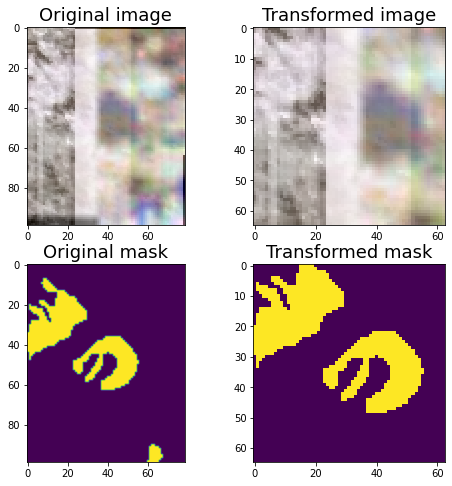

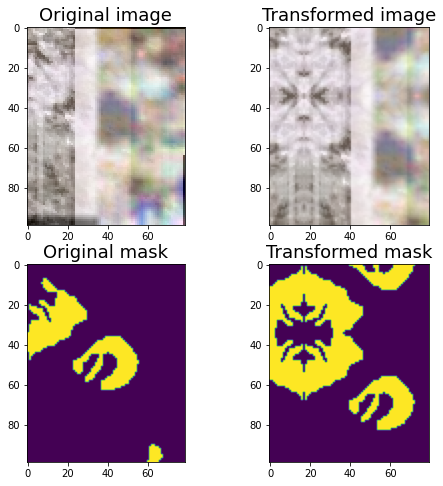

IndexError: ignored

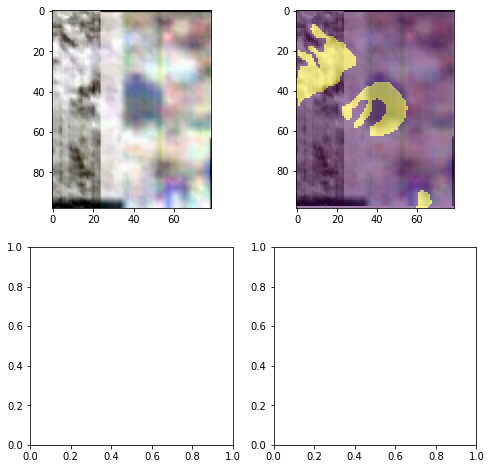

In [28]:
def visualize(image, mask, original_image=None, original_mask=None):
    fontsize = 18
    
    if original_image is None and original_mask is None:
        f, ax = plt.subplots(2, 1, figsize=(8, 8))

        ax[0].imshow(image)
        ax[1].imshow(mask)
    else:
        f, ax = plt.subplots(2, 2, figsize=(8, 8))

        ax[0, 0].imshow(original_image)
        ax[0, 0].set_title('Original image', fontsize=fontsize)
        
        ax[1, 0].imshow(original_mask)
        ax[1, 0].set_title('Original mask', fontsize=fontsize)
        
        ax[0, 1].imshow(image)
        ax[0, 1].set_title('Transformed image', fontsize=fontsize)
        
        ax[1, 1].imshow(mask)
        ax[1, 1].set_title('Transformed mask', fontsize=fontsize)

        plt.show()

if DEBUG: 
  i = 0
  nimg, nmsk = randomCrop(m_images[i], p_masks[i])
  visualize(nimg[:,:,:3], nmsk, original_image=m_images[i][:,:,:3], original_mask=p_masks[i])

  nimg = cv2.copyMakeBorder(nimg, 99 - nimg.shape[0], 0, 80 - nimg.shape[1], 0, cv2.BORDER_REFLECT_101)
  nmsk = cv2.copyMakeBorder(nmsk, 99 - nmsk.shape[0], 0, 80 - nmsk.shape[1], 0, cv2.BORDER_REFLECT_101)

  visualize(nimg[:,:,:3], nmsk, original_image=m_images[i][:,:,:3], original_mask=p_masks[i])

  img_resized = cv2.resize(scale_multispectral_image(m_images[0]), (79,98))
  mask_resized = cv2.resize(p_masks[0], (79,98))

  f, ax = plt.subplots(2, 2, figsize=(8, 8))

  ax[0,0].imshow(img_resized[:,:,:3])
  ax[0,1].imshow(img_resized[:,:,:3])
  #ax[0,1].imshow(mask_resized, alpha = .5)
  ax[0,1].imshow(p_masks[0], alpha = .5)

  ax[1,0].imshow(scale_multispectral_image(p_images[0]))
  ax[1,1].imshow(scale_multispectral_image(p_images[0]))
  ax[1,1].imshow(p_masks[0], alpha = .5)
  plt.show()

# Padding

In [29]:
def pad_images(imgs, msks):
  '''Pipeline function for images' padding. '''
  
  images, masks = [], []
  for i in range(len(imgs)):
    images.append(cv2.copyMakeBorder(imgs[i], 99 - imgs[i].shape[0], 0, 80 - imgs[i].shape[1], 0, cv2.BORDER_REFLECT_101))
    masks.append(cv2.copyMakeBorder(msks[i], 99 - msks[i].shape[0], 0, 80 - msks[i].shape[1], 0, cv2.BORDER_REFLECT_101))

  return images, masks

# Preprocessing Pipeline Function

In [31]:
def preprocessing_pipeline(method, scale = True): 
  if scale: scaling()
  pansharpening(method)
  data_augmentation()
  imgs, masks = pad_images(m_images, p_masks)

  return imgs, masks

m_images, p_masks = preprocessing_pipeline('Simple Mean')

# PyTorch Dataset

In [52]:
#from sklearn.preprocessing import *
from sklearn.decomposition import PCA

def apply_pca(X, transformer = False, components = -1):
    aux = X.copy()
    if transformer:
        X = pd.DataFrame(transformer.fit_transform(X))
        X.columns = aux.columns    
    # Create principal components
    if components == -1:
        pca = PCA()
    else:
        pca = PCA(n_components = components)
        
    X_pca = pca.fit_transform(X)
    # Convert to dataframe
    component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
    X_pca = pd.DataFrame(X_pca, columns=component_names)
    # Create loadings
    loadings = pd.DataFrame(
        pca.components_.T,  # transpose the matrix of loadings
        columns=component_names,  # so the columns are the principal components
        index=X.columns,  # and the rows are the original features
    )
    return pca, X_pca, loadings

def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2, sharey = True)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance")    # ylim = (0.0, 1.0) o sino sharey en plt.subplots
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance"
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

def pca_image(img, components = 3, return_pca = False): 
  ''' Performs a PCA and returns a 3-band image with the more significant bands. '''

  image = img.permute(1,2,0).numpy()

  b0 = image[:,:,0]
  b1 = image[:,:,1]
  b2 = image[:,:,2]
  b3 = image[:,:,3]
  b4 = image[:,:,4]
  b5 = image[:,:,5]
  b6 = image[:,:,6]
  b7 = image[:,:,7]

  pca_df = pd.DataFrame({'B0': b0.flatten(), 'B1': b1.flatten(), 'B2': b2.flatten(), 'B3':b3.flatten(), 
              'B4': b4.flatten(), 'B5': b5.flatten(), 'B6': b6.flatten(), 'B7':b7.flatten()})
  
  global_pca, X_pca, loadings = apply_pca(pca_df)

  #X_pca = global_pca.transform(pca_df)
  component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
  X_pca = pd.DataFrame(X_pca, columns=component_names)

  sc = MinMaxScaler()
  if components == 3: 
    img = X_pca.loc[:,:'PC3']
    img = pd.DataFrame(sc.fit_transform(img))
    img = img.values.reshape((image.shape[0], image.shape[1], 3))
  
  elif components == 8: 
    img = X_pca
    img = pd.DataFrame(sc.fit_transform(img))
    img = img.values.reshape((image.shape[0], image.shape[1], 8))

  if return_pca == True: return torch.from_numpy(img.astype(float)).permute(2,0,1), global_pca
  else: return torch.from_numpy(img.astype(float)).permute(2,0,1)

def vegetation_indexes(img):
  ''' Returns 3 selected vegetation indexes for the image given.

      %0	Coastal	400	425	450	50	1.24	
      %1	Blue	450	480	510	60	1.24	
      %2	Green	510	545	580	70	1.24	
      %3	Yellow	585	605	625	40	1.24	
      %4	Red	630	660	690	60	1.24	
      %5	Red Edge	705	725	745	40	1.24	
      %6	Near-IR1	770	832.5	895	125	1.24	
      %7	Near-IR2	860	950	1040	180	1.24

      * Normalized Difference Vegetation Index (NDVI) -> (NIR2-Red)/(NIR2 + Red)	UAV/WV-3
      * Green Normalized Difference Vegetation Index  -> (GNDVI)	(NIR2-Green)/(NIR2 + Green)	UAV/WV-3
      * Structure Insensitive Pigment Index (SIPI)	  ->  (NIR1-Blue)/(NIR1 + Red)	WV-3'''

  # Colour Bands
  nir1 = img[6,:,:]
  nir2 = img[7,:,:]
  red = img[4,:,:]
  green = img[2,:,:]
  blue = img[1,:,:]

  # Vegetation Indexes
  ndvi = (nir2 - red) / (nir2 + red)
  gndvi = (nir2 - green) / (nir2 + green)
  sipi = (nir1 - blue) / (nir1 + red)

  img = torch.stack([ndvi, gndvi, sipi], axis = 0)
  img = torch.clamp(img, min=-50, max=50)
  return img

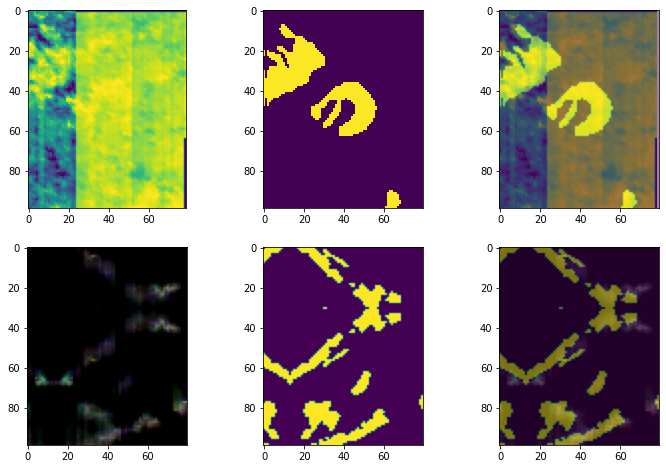

In [53]:
class PanchromaticDataset(torch.utils.data.Dataset):
    def __init__(self, images, masks):
      super().__init__()
      self.images = images 
      self.masks = masks 

    def __getitem__(self, i):
      return torch.from_numpy(self.images[i].astype(float)), torch.from_numpy(self.masks[i].astype(float))
        
    def __len__(self):
      return len(self.images)

class MultispectralDataset(torch.utils.data.Dataset):
  def __init__(self, images, masks, approach):
    super().__init__()
    self.images = images 
    self.masks = masks 
    self.approach = approach

  def __getitem__(self, i):
    img, mask = torch.from_numpy(self.images[i].astype(float)).permute(2,0,1), torch.from_numpy(self.masks[i].astype(float))
    
    if self.approach == '': return img, mask
    if self.approach == 'vegetation indexes': return torch.nan_to_num(vegetation_indexes(img)), mask
    if self.approach == 'pca': return pca_image(img), mask

  def __len__(self):
      return len(self.images)

panchromatic_dataset = PanchromaticDataset(p_images, p_masks)
multispectral_dataset = MultispectralDataset(m_images, p_masks, 'vegetation indexes')

if DEBUG: 
  fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (12,8))

  # Panchromatic
  img, mask = panchromatic_dataset[0]

  axes[0,0].imshow(img)
  axes[0,1].imshow(mask)
  axes[0,2].imshow(img)
  axes[0,2].imshow(mask, alpha = .5)
  
  # Multispectral
  img, mask = multispectral_dataset[1063]

  axes[1,0].imshow(img.permute(1,2,0)[:,:,:3])
  axes[1,1].imshow(mask)
  axes[1,2].imshow(img.permute(1,2,0)[:,:,:3])
  axes[1,2].imshow(mask, alpha = .5)

In [49]:
# Saving PyTorch Datasets

torch.save(panchromatic_dataset, 'gdrive/MyDrive/panchromatic_dataset.pt')
torch.save(multispectral_dataset, 'gdrive/MyDrive/multispectral_dataset.pt')